# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [7]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

In [8]:
#I am using the income inequality dataset from the Standardised World Income Inequality Database - which I downloaded as a .csv file from the Harvard Dataverse from this link: https://dataverse.harvard.edu/file.xhtml?fileId=13657070&version=16.0
#I'm using version 8-9 which is the latest dataset available.

In [9]:
income_inequality_data_filepath = "/Users/sheena/Desktop/datascience-publicpolicy-2026-main/notebooks/hw/hw_3/swiid9_92_summary.csv"
income_inequality_data = pd.read_csv(income_inequality_data_filepath)
print(income_inequality_data.shape)

(6628, 10)


In [10]:
income_inequality_data

,country,year,gini_disp,gini_disp_se,gini_mkt,gini_mkt_se,abs_red,abs_red_se,rel_red,rel_red_se
0,Afghanistan,2007,31.4,2.48,32.7,2.72,NaN,NaN,NaN,NaN
1,Afghanistan,2008,31.4,2.40,32.8,2.65,NaN,NaN,NaN,NaN
2,Afghanistan,2009,31.5,2.45,32.9,2.72,NaN,NaN,NaN,NaN
3,Afghanistan,2010,31.6,2.47,33.0,2.76,NaN,NaN,NaN,NaN
4,Afghanistan,2011,31.7,2.49,33.1,2.75,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6623,Zimbabwe,2015,47.4,3.19,49.3,3.43,NaN,NaN,NaN,NaN
6624,Zimbabwe,2016,47.5,3.24,49.4,3.46,NaN,NaN,NaN,NaN
6625,Zimbabwe,2017,47.5,3.27,49.5,3.48,NaN,NaN,NaN,NaN
6626,Zimbabwe,2018,47.6,3.37,49.5,3.58,NaN,NaN,NaN,NaN


### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [11]:
income_inequality_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6628 entries, 0 to 6627
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       6628 non-null   object 
 1   year          6628 non-null   int64  
 2   gini_disp     6628 non-null   float64
 3   gini_disp_se  6628 non-null   float64
 4   gini_mkt      6628 non-null   float64
 5   gini_mkt_se   6628 non-null   float64
 6   abs_red       2756 non-null   float64
 7   abs_red_se    2756 non-null   float64
 8   rel_red       2756 non-null   float64
 9   rel_red_se    2756 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 517.9+ KB


In [12]:
income_inequality_data.head(5)

,country,year,gini_disp,gini_disp_se,gini_mkt,gini_mkt_se,abs_red,abs_red_se,rel_red,rel_red_se
0,Afghanistan,2007,31.4,2.48,32.7,2.72,NaN,NaN,NaN,NaN
1,Afghanistan,2008,31.4,2.40,32.8,2.65,NaN,NaN,NaN,NaN
2,Afghanistan,2009,31.5,2.45,32.9,2.72,NaN,NaN,NaN,NaN
3,Afghanistan,2010,31.6,2.47,33.0,2.76,NaN,NaN,NaN,NaN
4,Afghanistan,2011,31.7,2.49,33.1,2.75,NaN,NaN,NaN,NaN


In [13]:
income_inequality_data.tail(10)

,country,year,gini_disp,gini_disp_se,gini_mkt,gini_mkt_se,abs_red,abs_red_se,rel_red,rel_red_se
6618,Zimbabwe,2010,47.3,3.04,49.1,3.22,NaN,NaN,NaN,NaN
6619,Zimbabwe,2011,47.2,2.97,49.1,3.18,NaN,NaN,NaN,NaN
6620,Zimbabwe,2012,47.3,3.03,49.1,3.26,NaN,NaN,NaN,NaN
6621,Zimbabwe,2013,47.3,3.11,49.2,3.32,NaN,NaN,NaN,NaN
6622,Zimbabwe,2014,47.4,3.15,49.3,3.38,NaN,NaN,NaN,NaN
6623,Zimbabwe,2015,47.4,3.19,49.3,3.43,NaN,NaN,NaN,NaN
6624,Zimbabwe,2016,47.5,3.24,49.4,3.46,NaN,NaN,NaN,NaN
6625,Zimbabwe,2017,47.5,3.27,49.5,3.48,NaN,NaN,NaN,NaN
6626,Zimbabwe,2018,47.6,3.37,49.5,3.58,NaN,NaN,NaN,NaN
6627,Zimbabwe,2019,47.7,3.45,49.6,3.69,NaN,NaN,NaN,NaN


In [14]:
inequality_data = income_inequality_data

In [15]:
inequality_data = income_inequality_data.rename(columns = {
    "gini_mkt": "Market Gini",
    "gini_disp": "Disposable Gini",
    "country": "Country",
    "year": "Year"
})

In [16]:
# 3. Filter row or column filters if necessary
cols = ["Country", "Year", "Market Gini", "Disposable Gini"]
df_inequality = inequality_data[cols]
df_inequality.head(5)


,Country,Year,Market Gini,Disposable Gini
0,Afghanistan,2007,32.7,31.4
1,Afghanistan,2008,32.8,31.4
2,Afghanistan,2009,32.9,31.5
3,Afghanistan,2010,33.0,31.6
4,Afghanistan,2011,33.1,31.7


In [17]:
countries = ['Australia', 'Canada', 'United Kingdom', 'New Zealand']
years = [2010, 2015, 2020, 2025]  
df_inequality = df_inequality.query("Country in @countries and Year in @years")
df_inequality.head(15)


,Country,Year,Market Gini,Disposable Gini
250,Australia,2010,48.2,33.0
255,Australia,2015,48.4,32.7
260,Australia,2020,48.1,32.6
903,Canada,2010,47.9,31.8
908,Canada,2015,47.9,31.6
913,Canada,2020,48.3,28.7
4139,New Zealand,2010,47.7,32.0
4144,New Zealand,2015,48.1,32.7
4149,New Zealand,2020,47.7,31.2
6247,United Kingdom,2010,54.3,32.0


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [19]:
#I'm now going to use my second data set - happiness index data from the World Happiness Report, which I downloaded as a an excel file from this link: https://worldhappiness.report/ed/2023/#appendices-and-data

In [18]:
# 1. Load and clean the secondary dataset
df = pd.read_excel("/Users/sheena/Desktop/datascience-publicpolicy-2026-main/notebooks/hw/hw_3/WHR26_Data_Figure_2.1 (1).xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   object 
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by

In [20]:
df.head(10)

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041
5,2025,6,Norway,7.242,7.156,7.327,2.057,1.626,0.983,1.092,0.157,0.413,0.913
6,2025,7,Netherlands,7.223,7.153,7.293,1.983,1.539,0.922,1.000,0.175,0.349,1.255
7,2025,8,Israel,7.187,7.119,7.254,1.867,1.606,0.925,0.863,0.139,0.196,1.592
8,2025,9,Luxembourg,7.063,6.971,7.154,2.162,1.465,0.981,1.056,0.111,0.382,0.907
9,2025,10,Switzerland,7.018,6.937,7.099,2.028,1.534,1.017,1.035,0.148,0.452,0.804


In [21]:
df_happiness = df[["Country name", "Year", "Rank", "Life evaluation (3-year average)"]]
df_happiness = df_happiness.rename(columns = {
    "Country name": "Country",
    "Rank": "Happiness Rank",
    "Life evaluation (3-year average)" : "Life Evaluation score"})

In [22]:
countries = ['Australia', 'Canada', 'United Kingdom', 'New Zealand']
years = [2010, 2015, 2020, 2025] 
df_happiness = df_happiness.query("Country in @countries and Year in @years")
df_happiness.head(10)

,Country,Year,Happiness Rank,Life Evaluation score
10,New Zealand,2025,11,6.995
14,Australia,2025,15,6.916
24,Canada,2025,25,6.741
28,United Kingdom,2025,29,6.694
728,New Zealand,2020,9,7.277
730,Australia,2020,11,7.183
733,Canada,2020,14,7.103
736,United Kingdom,2020,17,7.064
1494,Canada,2015,6,7.404
1496,New Zealand,2015,8,7.334


In [23]:
# 2. Merge your datasets on a common key
df_merged = pd.merge(df_happiness, df_inequality, on=['Country', 'Year'])
df_merged = df_merged[['Country', 'Year', 'Life Evaluation score', 'Market Gini', 'Disposable Gini']].dropna()
print(f"Total merged records: {len(df_merged)}")
df_merged.head(10)

Total merged records: 8


,Country,Year,Life Evaluation score,Market Gini,Disposable Gini
0,New Zealand,2020,7.277,47.7,31.2
1,Australia,2020,7.183,48.1,32.6
2,Canada,2020,7.103,48.3,28.7
3,United Kingdom,2020,7.064,52.9,30.9
4,Canada,2015,7.404,47.9,31.6
5,New Zealand,2015,7.334,48.1,32.7
6,Australia,2015,7.313,48.4,32.7
7,United Kingdom,2015,6.725,53.6,31.3


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*

In [128]:
#I used Country and Year are the matching key - they are the only two columns that are common between the two datasets. I also dropped any records with missing values in the merged dataset. 
#There were a total of 8 matching rows which were successfully kept after merging, the result was limited because the happiness data isn't available before 2015.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [24]:
# Apply groupby aggregation or implement one of the backup grouping strategies
threshold = df_merged['Disposable Gini'].median()
print(f"Median Disposable Gini: {threshold}")


Median Disposable Gini: 31.450000000000003


In [25]:
df_merged['Inequality Group'] = df_merged['Disposable Gini'].apply(
    lambda x: 'High Inequality' if x> threshold else 'Low Inequality')
threshold_agg = df_merged.groupby('Inequality Group')[['Life Evaluation score', 'Market Gini', 'Disposable Gini']].mean()
print(threshold_agg)

                  Life Evaluation score  Market Gini  Disposable Gini
Inequality Group                                                     
High Inequality                 7.30850       48.125           32.400
Low Inequality                  7.04225       50.625           30.525


- *Extra Credit: Write your economic or policy related interpretation here*

In [26]:
# I wanted to determine if countries with above-median disposable income inequality have lower life satisfaction.
#  I wanted to test this first with a small group of countries, so I chose 4 major Commonwealth countries to see if the results would vary across them. 
# The results show that country + years with above-median inequality had higher average life satisfaction (7.31 vs. 7.04). 
# This is likely because Australia has consistently scores high on happiness and makes up most of the high inequality group. 
# With only 9 data points across 3 countries, it's hard to separate the effect of inequality from other country differences. 
# A larger, more diverse sample would be needed to draw stronger conclusions.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

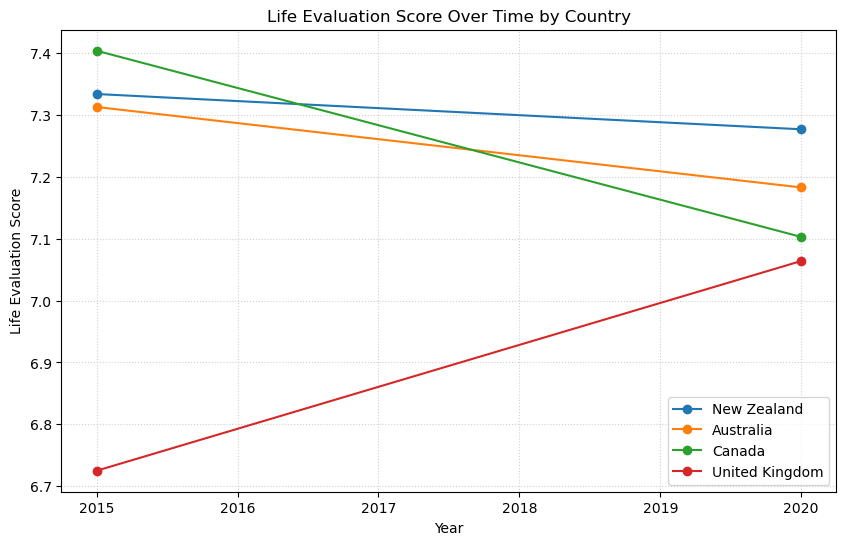

In [27]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
plt.figure(figsize=(10, 6))

for country in df_merged['Country'].unique():
    df_country = df_merged[df_merged['Country'] == country].sort_values('Year')
    plt.plot(df_country['Year'], df_country['Life Evaluation score'], marker='o', label=country)

plt.title("Life Evaluation Score Over Time by Country")
plt.xlabel("Year")
plt.ylabel("Life Evaluation Score")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

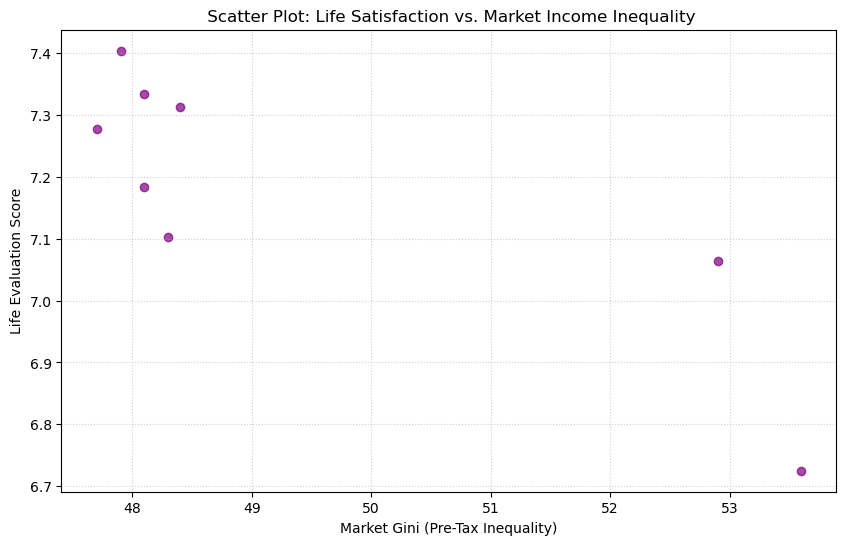

In [28]:
# Plot 2: Customized scatter plot of primary policy variables
plt.figure(figsize=(10, 6))
plt.scatter(x=df_merged['Market Gini'], y=df_merged['Life Evaluation score'], color='purple', alpha=0.7)

plt.title(" Scatter Plot: Life Satisfaction vs. Market Income Inequality")
plt.ylabel("Life Evaluation Score")
plt.xlabel("Market Gini (Pre-Tax Inequality)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

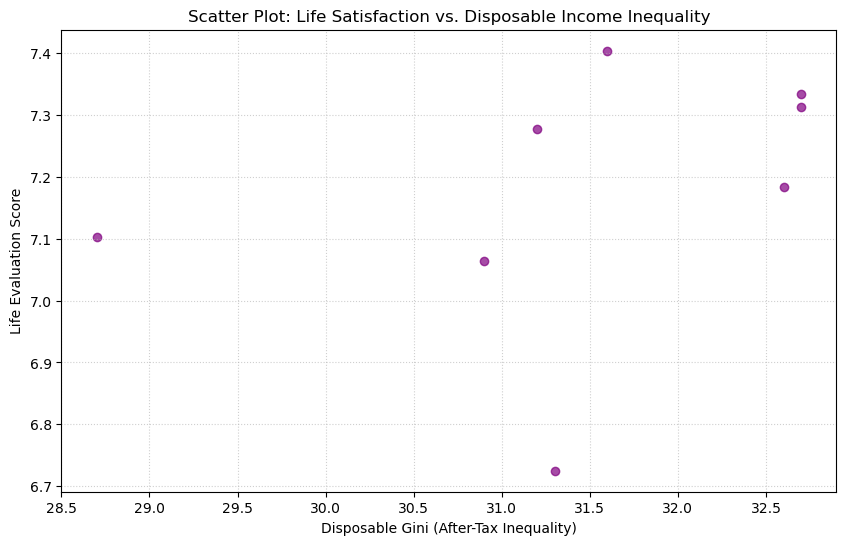

In [29]:
# Fit a simple linear regression and overlay the line of best fit
plt.figure(figsize=(10, 6))
plt.scatter(x=df_merged['Disposable Gini'], y=df_merged['Life Evaluation score'], color='purple', alpha=0.7)

plt.title("Scatter Plot: Life Satisfaction vs. Disposable Income Inequality")
plt.ylabel("Life Evaluation Score")
plt.xlabel("Disposable Gini (After-Tax Inequality)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

In [ ]:
#The visualisation and regressions unfortunately don't show a clear relationship between income inequality and life satisfaction.
#My decision to focus the analysis on such a small group of countries and years was clearly a big mistake as these results are really not useful at all.
#My next attempt will use a larger sample to hopefully produce some actually interesting/helpful results!


### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.